2026-02-27 03:18:31.046683: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772162311.423141      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772162311.574165      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772162312.507395      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772162312.507442      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772162312.507445      24 computation_placer.cc:177] computation placer alr

All Models Loaded Successfully ✅


I0000 00:00:1772162366.087646      68 service.cc:152] XLA service 0x7e8160004dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772162366.087685      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772162366.087691      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772162366.941352      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772162370.631260      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-02-27 03:19:50.392042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 03:19:50.528516: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured t


Image 1
Expected: Normal
ResNet50 Predicted: Normal
DenseNet121 Predicted: Normal
EfficientNetB0 Predicted: TB

Image 2
Expected: Pneumonia
ResNet50 Predicted: TB
DenseNet121 Predicted: TB
EfficientNetB0 Predicted: TB

Image 3
Expected: TB
ResNet50 Predicted: TB
DenseNet121 Predicted: TB
EfficientNetB0 Predicted: TB

Image 4
Expected: Normal
ResNet50 Predicted: Normal
DenseNet121 Predicted: Normal
EfficientNetB0 Predicted: TB

Image 5
Expected: Pneumonia
ResNet50 Predicted: TB
DenseNet121 Predicted: TB
EfficientNetB0 Predicted: TB


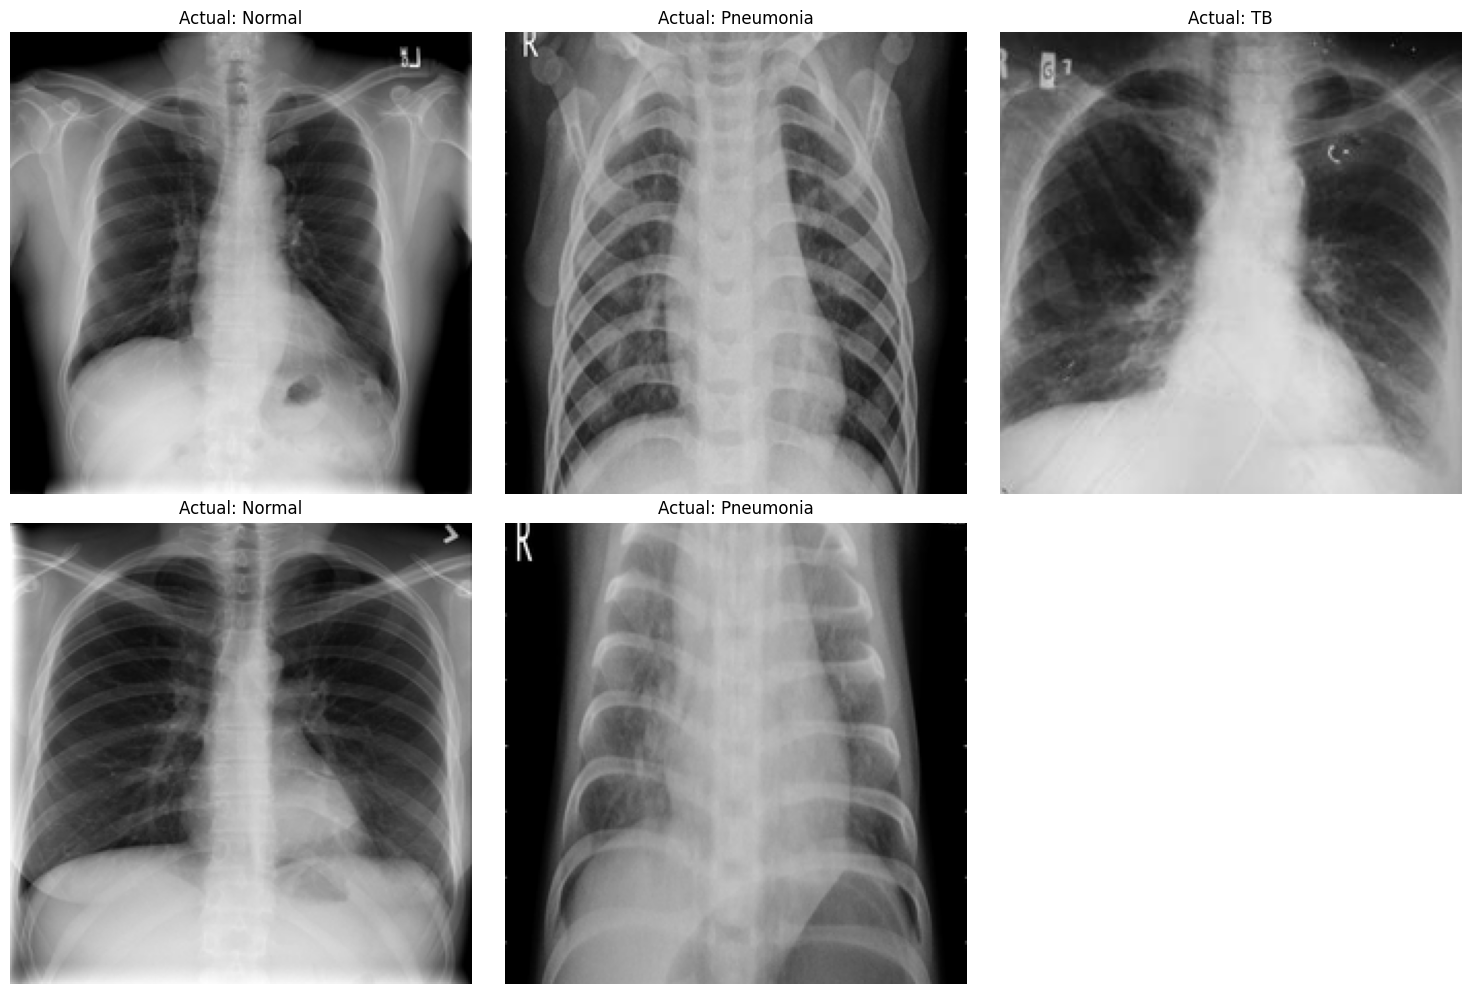

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# ===============================
# LOAD MODELS
# ===============================

resnet_model = load_model("/kaggle/input/datasets/hitakshigabani/resnet50/resnet50_best_74_acc.h5")
densenet_model = load_model("/kaggle/input/datasets/hitakshigabani/densenet121-model/densenet121_best_accuracy80.h5")
efficientnet_model = load_model("/kaggle/input/datasets/hitakshigabani/efficientnetb0/EfficientNetB0_Improved - 79.keras")

print("All Models Loaded Successfully ✅")

# ===============================
# SETTINGS
# ===============================

IMG_SIZE = 224
TEST_PATH = "/kaggle/input/datasets/hitakshigabani/dataset-tb-and-pneumoniadetection/chest-xray-dataset/test"

class_names = ["Normal", "Pneumonia", "TB"]

# ===============================
# SELECT 5 IMAGES
# ===============================

selected_images = []

# Pick at least one from each class
for class_name in class_names:
    class_folder = os.path.join(TEST_PATH, class_name)
    img_name = os.listdir(class_folder)[0]  # first image
    selected_images.append((os.path.join(class_folder, img_name), class_name))

# Add 2 more random images
for class_name in class_names[:2]:
    class_folder = os.path.join(TEST_PATH, class_name)
    img_name = os.listdir(class_folder)[1]
    selected_images.append((os.path.join(class_folder, img_name), class_name))

# ===============================
# PREDICT FUNCTION
# ===============================

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_resnet = resnet_model.predict(img_array, verbose=0)
    pred_densenet = densenet_model.predict(img_array, verbose=0)
    pred_efficient = efficientnet_model.predict(img_array, verbose=0)

    class_resnet = class_names[np.argmax(pred_resnet)]
    class_densenet = class_names[np.argmax(pred_densenet)]
    class_efficient = class_names[np.argmax(pred_efficient)]

    return class_resnet, class_densenet, class_efficient, img

# ===============================
# SHOW RESULTS
# ===============================

plt.figure(figsize=(15,10))

for i, (img_path, actual_label) in enumerate(selected_images):
    
    resnet_pred, densenet_pred, efficient_pred, img = predict_image(img_path)

    print(f"\nImage {i+1}")
    print("Expected:", actual_label)
    print("ResNet50 Predicted:", resnet_pred)
    print("DenseNet121 Predicted:", densenet_pred)
    print("EfficientNetB0 Predicted:", efficient_pred)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Actual: {actual_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()